# Anomaly detection by autoencoder with Keras

I'm a beginner in deep learning, so I'm sharing what I've learned.  I used [this blog](https://blog.keras.io/building-autoencoders-in-keras.html) as a reference.

The train data should be trained by autoencoder with "1" only, and the test data should be "0" and "1" only. For the restored image, check that "0" is not restored. Check the difference from the original image, and "0" can be detected as abnormal data.
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D
from keras.models import Model
from keras import regularizers

In [2]:
# Function to display images
def disp_img(img):
    n = 10  
    plt.figure(figsize=(20, 4))
    for i in range(n):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(img[i].reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

In [3]:
np.random.seed(42)

## Data Preparation
Use MNIST data from Digit Recognizer.

In [4]:
temp = pd.read_csv('../input/digit-recognizer/train.csv')
df01 = temp[temp['label'] < 2]
del temp

df_train = df01[df01['label'] == 1].drop(['label'],axis = 1)  #Train data is "1" only
train = df_train.values
train = train.astype('float32') / 255.

df_test = df01.drop(['label'],axis = 1).head(10)  #Test data is "0" and "1"
test = df_test.values
test = test.astype('float32') / 255.
del df01

Train data is **"1"** only

In [5]:
print(train.shape)

(4684, 784)


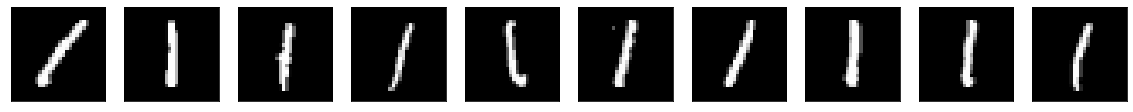

In [6]:
disp_img(train)

Test data is **"0" and "1"**

In [7]:
print(test.shape)

(10, 784)


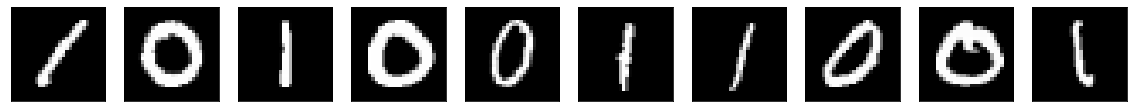

In [8]:
disp_img(test)

## Fully-connected neural layer
It was best to use binary cross-entropy as the loss function and adam as the optimization method.

In [9]:
def create_fullautoencoder(train, opt, loss):
    input_img = Input(shape=(784, ))
    encoded = Dense(32, activation='relu')(input_img)
    decoded = Dense(784, activation='sigmoid')(encoded)
    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer=opt, loss=loss)
    return(autoencoder)

### Differences in restored images due to optimization methods
The loss function is fixed to binary cross-entropy, and the differences between the restored images from the optimization methods are compared.
#### SGD
Stochastic Gradient Descent. Easy, but zigzagging is a violent movement and in some cases inefficient.  
SGD can't even reproduce "1"...

In [10]:
autoencoder1 = create_fullautoencoder(train, 'sgd', 'binary_crossentropy')
autoencoder1.fit(train, train, epochs=50, batch_size=256, shuffle=True)

Epoch 1/50
19/19 [==============================] - 1s 6ms/step - loss: 0.6928
Epoch 2/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6926
Epoch 3/50
19/19 [==============================] - 0s 5ms/step - loss: 0.6925
Epoch 4/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6924
Epoch 5/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6923
Epoch 6/50
19/19 [==============================] - 0s 5ms/step - loss: 0.6922
Epoch 7/50
19/19 [==============================] - 0s 5ms/step - loss: 0.6920
Epoch 8/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6919
Epoch 9/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6918
Epoch 10/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6917
Epoch 11/50
19/19 [==============================] - 0s 5ms/step - loss: 0.6916
Epoch 12/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6915
Epoch 13/50
19/19 [==============================

In [11]:
autoencoder1.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 784)]             0         
_________________________________________________________________
dense (Dense)                (None, 32)                25120     
_________________________________________________________________
dense_1 (Dense)              (None, 784)               25872     
Total params: 50,992
Trainable params: 50,992
Non-trainable params: 0
_________________________________________________________________


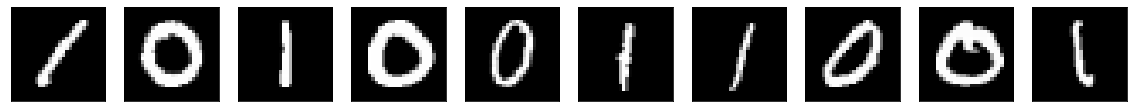

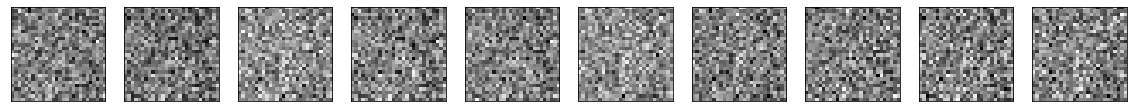

In [12]:
decoded1 = autoencoder1.predict(test)
disp_img(test)
disp_img(decoded1)

#### Adagrad
A method to automatically determine the learning rate.  Adagrad didn't work either...

In [13]:
autoencoder2 = create_fullautoencoder(train, 'adagrad', 'binary_crossentropy')
autoencoder2.fit(train, train, epochs=50, batch_size=256, shuffle=True)

Epoch 1/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6935
Epoch 2/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6934
Epoch 3/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6934
Epoch 4/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6933
Epoch 5/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6933
Epoch 6/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6932
Epoch 7/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6932
Epoch 8/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6931
Epoch 9/50
19/19 [==============================] - 0s 7ms/step - loss: 0.6931
Epoch 10/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6930
Epoch 11/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6930
Epoch 12/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6929
Epoch 13/50
19/19 [==============================

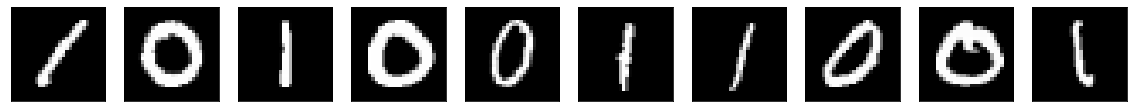

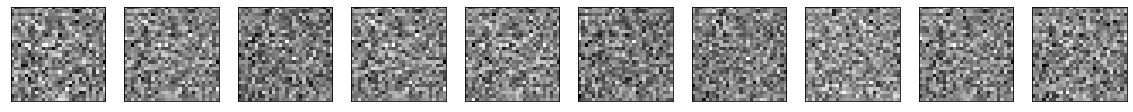

In [14]:
decoded2 = autoencoder2.predict(test)
disp_img(test)
disp_img(decoded2)

#### Adadelta
Prevent rapid and monotonous decline in learning rate with AdaGrad's developmental system.  

In [15]:
autoencoder3 = create_fullautoencoder(train, 'adadelta', 'binary_crossentropy')
autoencoder3.fit(train, train, epochs=50, batch_size=256, shuffle=True)

Epoch 1/50
19/19 [==============================] - 0s 7ms/step - loss: 0.6930
Epoch 2/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6929
Epoch 3/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6929
Epoch 4/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6929
Epoch 5/50
19/19 [==============================] - 0s 5ms/step - loss: 0.6929
Epoch 6/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6929
Epoch 7/50
19/19 [==============================] - 0s 7ms/step - loss: 0.6929
Epoch 8/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6929
Epoch 9/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6928
Epoch 10/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6928
Epoch 11/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6928
Epoch 12/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6928
Epoch 13/50
19/19 [==============================

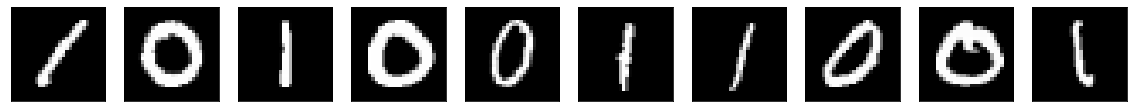

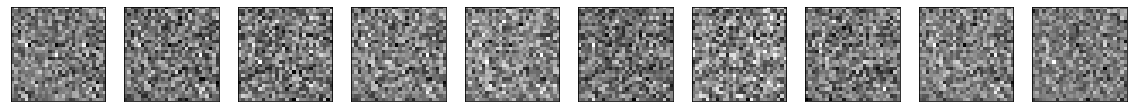

In [16]:
decoded3 = autoencoder3.predict(test)
disp_img(test)
disp_img(decoded3)

#### RMSprop
A method that solves the shortcomings of Adagrad by accumulating exponential moving averages.  
**Good job! As hoped, we can determine that the "0" is an anomaly because we can reproduce the "1" and not the "0".**

In [17]:
autoencoder4 = create_fullautoencoder(train, 'rmsprop', 'binary_crossentropy')
autoencoder4.fit(train, train, epochs=50, batch_size=256, shuffle=True)

Epoch 1/50
19/19 [==============================] - 0s 7ms/step - loss: 0.5752
Epoch 2/50
19/19 [==============================] - 0s 6ms/step - loss: 0.2121
Epoch 3/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1419
Epoch 4/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1138
Epoch 5/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0983
Epoch 6/50
19/19 [==============================] - 0s 5ms/step - loss: 0.0889
Epoch 7/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0832
Epoch 8/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0795
Epoch 9/50
19/19 [==============================] - 0s 7ms/step - loss: 0.0761
Epoch 10/50
19/19 [==============================] - 0s 7ms/step - loss: 0.0741
Epoch 11/50
19/19 [==============================] - 0s 5ms/step - loss: 0.0717
Epoch 12/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0688
Epoch 13/50
19/19 [==============================

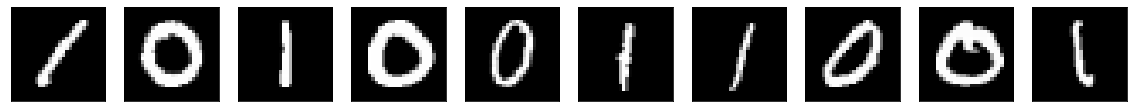

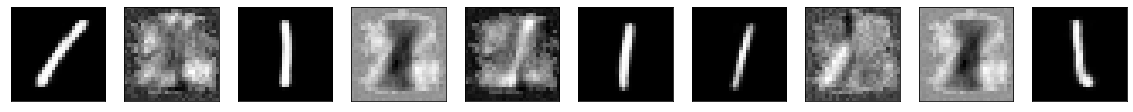

In [18]:
decoded4 = autoencoder4.predict(test)
disp_img(test)
disp_img(decoded4)

#### Adam
It's a combination of RMSprop and Momentum, but with some differences.  
**Good job! As hoped, we can determine that the "0" is an anomaly because we can reproduce the "1" and not the "0".**

In [19]:
autoencoder5 = create_fullautoencoder(train, 'adam', 'binary_crossentropy')
autoencoder5.fit(train, train, epochs=50, batch_size=256, shuffle=True)

Epoch 1/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6687
Epoch 2/50
19/19 [==============================] - 0s 6ms/step - loss: 0.4182
Epoch 3/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1844
Epoch 4/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1349
Epoch 5/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1181
Epoch 6/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1056
Epoch 7/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0970
Epoch 8/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0921
Epoch 9/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0896
Epoch 10/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0861
Epoch 11/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0833
Epoch 12/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0812
Epoch 13/50
19/19 [==============================

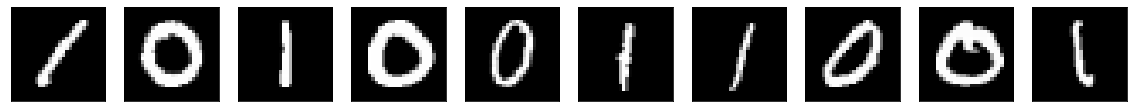

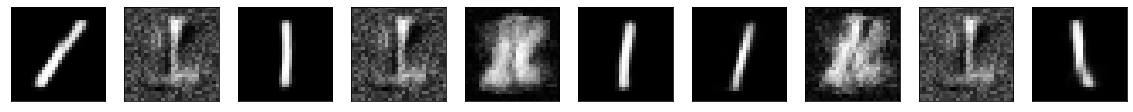

In [20]:
decoded5 = autoencoder5.predict(test)
disp_img(test)
disp_img(decoded5)

#### Nadam
Adam's take on Nesterov's Accelerated Gradient Method. This is ok too.

In [21]:
autoencoder6 = create_fullautoencoder(train, 'nadam', 'binary_crossentropy')
autoencoder6.fit(train, train, epochs=50, batch_size=256, shuffle=True)

Epoch 1/50
19/19 [==============================] - 1s 7ms/step - loss: 0.6581
Epoch 2/50
19/19 [==============================] - 0s 6ms/step - loss: 0.3270
Epoch 3/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1643
Epoch 4/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1346
Epoch 5/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1185
Epoch 6/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1064
Epoch 7/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0985
Epoch 8/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0937
Epoch 9/50
19/19 [==============================] - 0s 7ms/step - loss: 0.0897
Epoch 10/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0868
Epoch 11/50
19/19 [==============================] - 0s 7ms/step - loss: 0.0853
Epoch 12/50
19/19 [==============================] - 0s 7ms/step - loss: 0.0832
Epoch 13/50
19/19 [==============================

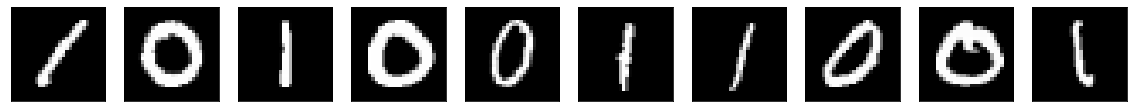

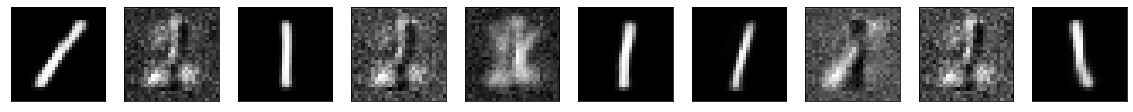

In [22]:
decoded6 = autoencoder6.predict(test)
disp_img(test)
disp_img(decoded6)

### Difference of restored image by loss function
The optimization method is fixed to adam, and the differences in the restored images due to the loss function are compared.
#### MSE
Mean square error. Successful anomaly detection.

In [23]:
autoencoder7 = create_fullautoencoder(train, 'adam', 'mean_squared_error')
autoencoder7.fit(train, train, epochs=50, batch_size=256, shuffle=True)

Epoch 1/50
19/19 [==============================] - 0s 4ms/step - loss: 0.2255
Epoch 2/50
19/19 [==============================] - 0s 5ms/step - loss: 0.1024
Epoch 3/50
19/19 [==============================] - 0s 4ms/step - loss: 0.0345
Epoch 4/50
19/19 [==============================] - 0s 4ms/step - loss: 0.0278
Epoch 5/50
19/19 [==============================] - 0s 4ms/step - loss: 0.0235
Epoch 6/50
19/19 [==============================] - 0s 4ms/step - loss: 0.0209
Epoch 7/50
19/19 [==============================] - 0s 4ms/step - loss: 0.0183
Epoch 8/50
19/19 [==============================] - 0s 4ms/step - loss: 0.0171
Epoch 9/50
19/19 [==============================] - 0s 4ms/step - loss: 0.0154
Epoch 10/50
19/19 [==============================] - 0s 4ms/step - loss: 0.0149
Epoch 11/50
19/19 [==============================] - 0s 4ms/step - loss: 0.0143
Epoch 12/50
19/19 [==============================] - 0s 4ms/step - loss: 0.0140
Epoch 13/50
19/19 [==============================

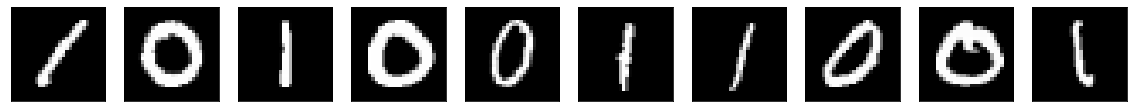

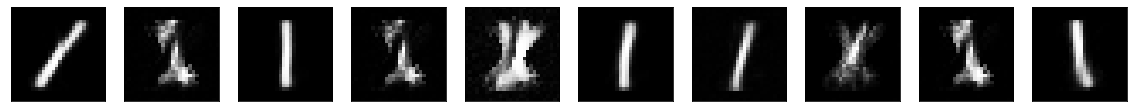

In [24]:
decoded7 = autoencoder7.predict(test)
disp_img(test)
disp_img(decoded7)

#### Binary crossentropy
Again, we will run it again to compare it with the other loss functions.  
Successful anomaly detection.

In [25]:
autoencoder8 = create_fullautoencoder(train, 'adam', 'binary_crossentropy')
autoencoder8.fit(train, train, epochs=50, batch_size=256, shuffle=True)

Epoch 1/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6693
Epoch 2/50
19/19 [==============================] - 0s 6ms/step - loss: 0.4120
Epoch 3/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1722
Epoch 4/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1293
Epoch 5/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1118
Epoch 6/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1008
Epoch 7/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0929
Epoch 8/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0893
Epoch 9/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0860
Epoch 10/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0844
Epoch 11/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0822
Epoch 12/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0805
Epoch 13/50
19/19 [==============================

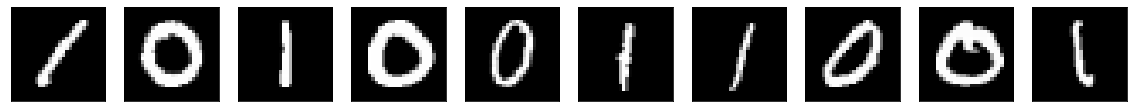

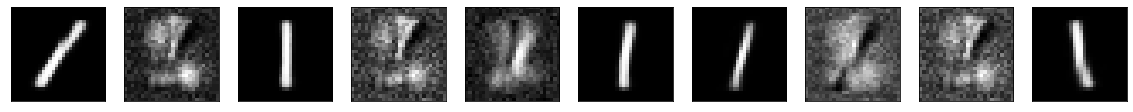

In [26]:
decoded8 = autoencoder8.predict(test)
disp_img(test)
disp_img(decoded8)

### KL divergence
It didn't work at all.

In [27]:
autoencoder9 = create_fullautoencoder(train, 'adam', 'kullback_leibler_divergence')
autoencoder9.fit(train, train, epochs=50, batch_size=256, shuffle=True)

Epoch 1/50
19/19 [==============================] - 0s 6ms/step - loss: 27.2194
Epoch 2/50
19/19 [==============================] - 0s 6ms/step - loss: 11.1278
Epoch 3/50
19/19 [==============================] - 0s 5ms/step - loss: -7.2003
Epoch 4/50
19/19 [==============================] - 0s 5ms/step - loss: -11.2821
Epoch 5/50
19/19 [==============================] - 0s 6ms/step - loss: -11.9658
Epoch 6/50
19/19 [==============================] - 0s 6ms/step - loss: -12.1830
Epoch 7/50
19/19 [==============================] - 0s 6ms/step - loss: -12.2854
Epoch 8/50
19/19 [==============================] - 0s 6ms/step - loss: -12.2826
Epoch 9/50
19/19 [==============================] - 0s 6ms/step - loss: -12.3200
Epoch 10/50
19/19 [==============================] - 0s 6ms/step - loss: -12.3708
Epoch 11/50
19/19 [==============================] - 0s 6ms/step - loss: -12.3697
Epoch 12/50
19/19 [==============================] - 0s 6ms/step - loss: -12.3555
Epoch 13/50
19/19 [=========

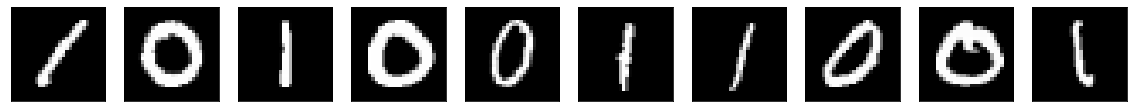

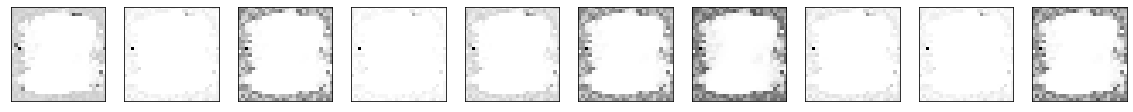

In [28]:
decoded9 = autoencoder9.predict(test)
disp_img(test)
disp_img(decoded9)

## Sparse autoencoder
Adds sparse regularization to a simple autoencoder.  

For fully connected neural layers, the best results were obtained using binary cross entropy as the loss function and adam as the optimization method, so we will use this combination in the future. 

Successful anomaly detection.

In [29]:
def create_sparseautoencoder(train, opt, loss):
    input_img = Input(shape=(784, ))
    encoded = Dense(32, activation='relu', 
                    activity_regularizer=regularizers.l1(10e-5))(input_img)
    decoded = Dense(784, activation='sigmoid')(encoded)
    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer=opt, loss=loss)
    return(autoencoder)

In [30]:
autoencoder10 = create_sparseautoencoder(train, 'adam', 'binary_crossentropy')
autoencoder10.fit(train, train, epochs=50, batch_size=256, shuffle=True)

Epoch 1/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6738
Epoch 2/50
19/19 [==============================] - 0s 6ms/step - loss: 0.4420
Epoch 3/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1933
Epoch 4/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1405
Epoch 5/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1231
Epoch 6/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1111
Epoch 7/50
19/19 [==============================] - 0s 6ms/step - loss: 0.1050
Epoch 8/50
19/19 [==============================] - 0s 7ms/step - loss: 0.0997
Epoch 9/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0969
Epoch 10/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0924
Epoch 11/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0901
Epoch 12/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0877
Epoch 13/50
19/19 [==============================

In [31]:
autoencoder10.summary()

Model: "model_9"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_10 (InputLayer)        [(None, 784)]             0         
_________________________________________________________________
dense_18 (Dense)             (None, 32)                25120     
_________________________________________________________________
dense_19 (Dense)             (None, 784)               25872     
Total params: 50,992
Trainable params: 50,992
Non-trainable params: 0
_________________________________________________________________


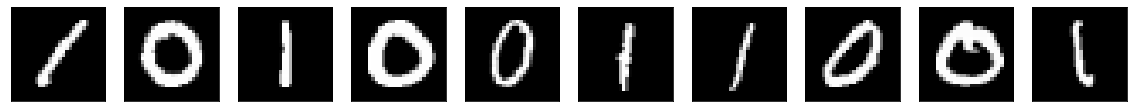

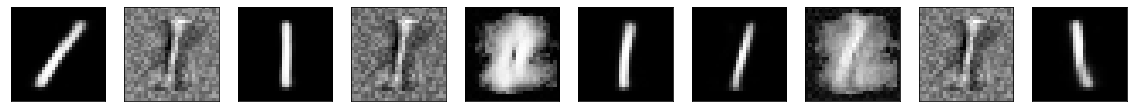

In [32]:
decoded10 = autoencoder10.predict(test)
disp_img(test)
disp_img(decoded10)

### Deep autoencoder
Successful anomaly detection.

In [33]:
def create_deepautoencoder(train, opt, loss):
    input_img = Input(shape=(784,))
    encoded = Dense(128, activation='relu')(input_img)
    encoded = Dense(64, activation='relu')(encoded)
    encoded = Dense(32, activation='relu')(encoded)
    decoded = Dense(64, activation='relu')(encoded)
    decoded = Dense(128, activation='relu')(decoded)
    decoded = Dense(784, activation='sigmoid')(decoded)
    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer=opt, loss=loss)
    return(autoencoder)

In [34]:
autoencoder11 = create_deepautoencoder(train, 'adam', 'binary_crossentropy')
autoencoder11.fit(train, train, epochs=50, batch_size=256, shuffle=True)

Epoch 1/50
19/19 [==============================] - 1s 10ms/step - loss: 0.6302
Epoch 2/50
19/19 [==============================] - 0s 10ms/step - loss: 0.1691
Epoch 3/50
19/19 [==============================] - 0s 10ms/step - loss: 0.1195
Epoch 4/50
19/19 [==============================] - 0s 10ms/step - loss: 0.0980
Epoch 5/50
19/19 [==============================] - 0s 10ms/step - loss: 0.0860
Epoch 6/50
19/19 [==============================] - 0s 10ms/step - loss: 0.0807
Epoch 7/50
19/19 [==============================] - 0s 10ms/step - loss: 0.0775
Epoch 8/50
19/19 [==============================] - 0s 9ms/step - loss: 0.0757
Epoch 9/50
19/19 [==============================] - 0s 9ms/step - loss: 0.0731
Epoch 10/50
19/19 [==============================] - 0s 10ms/step - loss: 0.0704
Epoch 11/50
19/19 [==============================] - 0s 10ms/step - loss: 0.0683
Epoch 12/50
19/19 [==============================] - 0s 10ms/step - loss: 0.0650
Epoch 13/50
19/19 [====================

In [35]:
autoencoder11.summary()

Model: "model_10"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_11 (InputLayer)        [(None, 784)]             0         
_________________________________________________________________
dense_20 (Dense)             (None, 128)               100480    
_________________________________________________________________
dense_21 (Dense)             (None, 64)                8256      
_________________________________________________________________
dense_22 (Dense)             (None, 32)                2080      
_________________________________________________________________
dense_23 (Dense)             (None, 64)                2112      
_________________________________________________________________
dense_24 (Dense)             (None, 128)               8320      
_________________________________________________________________
dense_25 (Dense)             (None, 784)               101

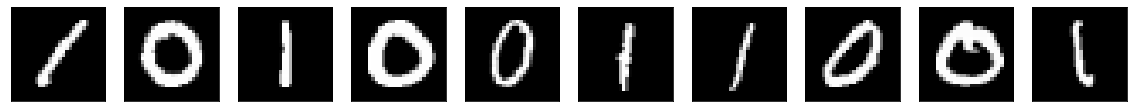

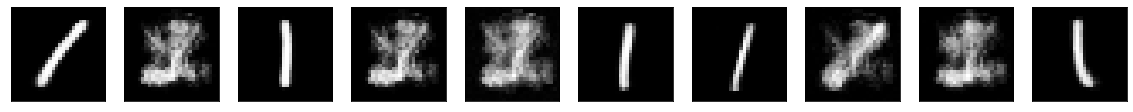

In [36]:
decoded11 = autoencoder11.predict(test)
disp_img(test)
disp_img(decoded11)

### Convolutional autoencoder
This is an auto-encoder that uses CNN.  

CNN even goes so far as to restore the "0". Therefore, a simple black and white image like MNIST may be difficult to detect anomalies, but may be suitable for anomaly detection of fine details like cracks in concrete.

In [37]:
def create_deepautoencoder(train, opt, loss):
    input_img = Input(shape=(28, 28, 1))
    x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)
    
    x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(16, (3, 3), activation='relu')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    
    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    return(autoencoder)

In [38]:
train = np.reshape(train, (len(train), 28, 28, 1))
test = np.reshape(test, (len(test), 28, 28, 1))

autoencoder12 = create_deepautoencoder(train, 'adam', 'binary_crossentropy')
autoencoder12.fit(train, train, epochs=50, batch_size=256, shuffle=True)

Epoch 1/50
19/19 [==============================] - 3s 128ms/step - loss: 0.6070
Epoch 2/50
19/19 [==============================] - 2s 129ms/step - loss: 0.3529
Epoch 3/50
19/19 [==============================] - 2s 128ms/step - loss: 0.2442
Epoch 4/50
19/19 [==============================] - 2s 128ms/step - loss: 0.1669
Epoch 5/50
19/19 [==============================] - 2s 129ms/step - loss: 0.1294
Epoch 6/50
19/19 [==============================] - 2s 127ms/step - loss: 0.1041
Epoch 7/50
19/19 [==============================] - 2s 128ms/step - loss: 0.0888
Epoch 8/50
19/19 [==============================] - 2s 127ms/step - loss: 0.0768
Epoch 9/50
19/19 [==============================] - 3s 135ms/step - loss: 0.0696
Epoch 10/50
19/19 [==============================] - 2s 129ms/step - loss: 0.0663
Epoch 11/50
19/19 [==============================] - 2s 127ms/step - loss: 0.0636
Epoch 12/50
19/19 [==============================] - 2s 127ms/step - loss: 0.0625
Epoch 13/50
19/19 [======

In [39]:
autoencoder12.summary()

Model: "model_11"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_12 (InputLayer)        [(None, 28, 28, 1)]       0         
_________________________________________________________________
conv2d (Conv2D)              (None, 28, 28, 16)        160       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 14, 14, 16)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 14, 14, 8)         1160      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 7, 7, 8)           0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 7, 7, 8)           584       
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 4, 4, 8)           0  

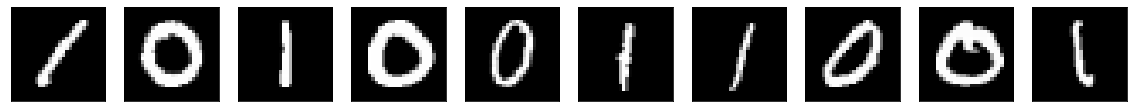

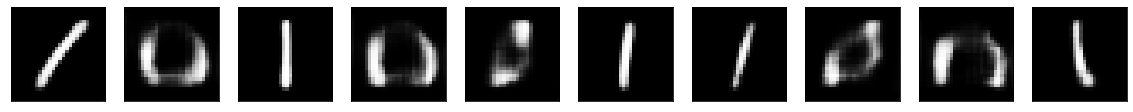

In [40]:
decoded12 = autoencoder12.predict(test)
disp_img(test)
disp_img(decoded12)

In this case, the parameters of the optimizer were left at the default settings, but you may get different results if you adjust them.